## 1. Import libraries & load the Cleaned Dataset

_Loading the cleaned dataset (from the ETL notebook) as the starting point for exploratory data analysis and churn risk visualisation._

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #imprting libraries for visualization

# Load cleaned data
df = pd.read_csv("../data/cleaned/BankChurners_cleaned.csv")

# Set visualization style
sns.set_theme(style="whitegrid")

In [21]:
df.head() #to display the first 5 rows of the dataset

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [22]:
df.shape #to show the number of rows and columns in the dataset

(10127, 21)

## 2. Univariate Overview: Numeric Columns

_Before churn-specific analysis, plotting histograms for every numeric column to understand each variable's distribution — checking for skew, spread, and anything unusual._

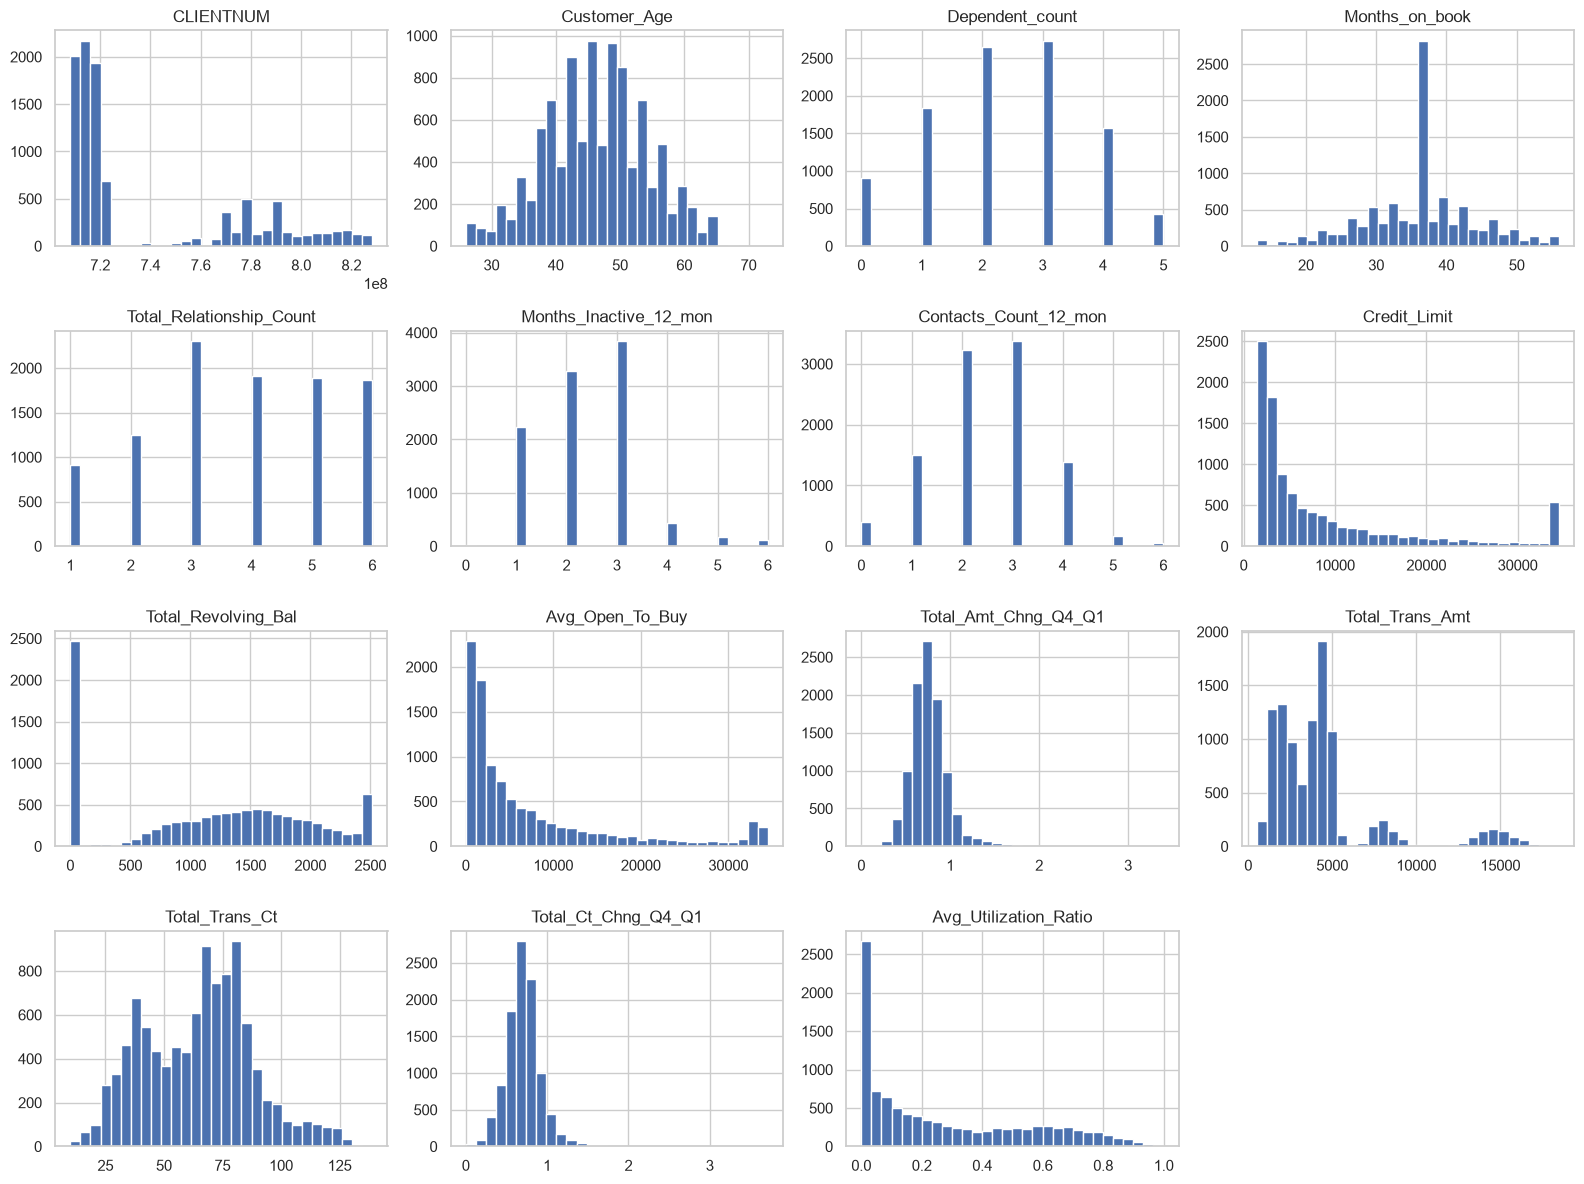

In [23]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

df.select_dtypes(include='number').hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show() # Display the histogram

**Observations:**
- 
- *_Credit_Limit_* is heavily right-skewed, with most customers holding lower limits and a small cluster at the maximum (~$34,500), suggesting a possible cap in the data.

- _Total_Revolving_Bal_ shows two distinct customer behaviours: a large spike at $0 (customers who carry no balance) alongside a separate cluster around $2,500.

- _Total_Trans_Ct_ and _Total_Trans_Amt_ are both bimodal, suggesting two underlying groups of customer transaction behaviour, worth investigating against churn status later.

- _Months_on_book_ shows an unusual spike at exactly 36 months, likely a default or placeholder value rather than a true customer tenure.

- _Total_Amt_Chng_Q4_Q1_ is a spending-change ratio: values near 1 indicate stable spending, values above 1 indicate increased spending, and values near 0 indicate a sharp spending drop — a strong candidate to compare against churn later.

- _CLIENTNUM_ is a unique identifier and not analytically meaningful — excluded from interpretation.


## 2. Descriptive Analysis

### 2.1 Overall Churn Rate

_Visualising the overall proportion of churned vs active customers as a baseline for the rest of the analysis._

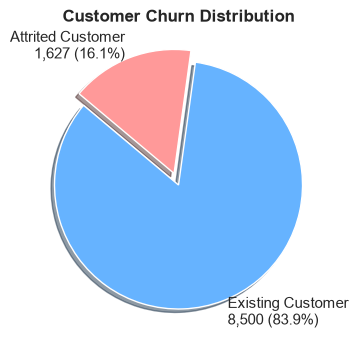

In [24]:
# Calculate counts and percentages
churn_counts = df['Attrition_Flag'].value_counts()
churn_percentage = (churn_counts / churn_counts.sum()) * 100

# Format custom labels using 'percentage'
labels_with_percentage = [
    f"{label}\n{count:,} ({percentage:.1f}%)" 
    for label, count, percentage in zip(churn_counts.index, churn_counts, churn_percentage) 
]  #zipping the labels, counts, and percentages together


# Create Pie Chart
plt.figure(figsize=(4, 6))
plt.pie(
    churn_counts, 
    labels=labels_with_percentage, # Display custom labels with counts and percentages
    startangle=140, # rotates the start of the pie chart
    colors=['#66b3ff', '#ff9999'], 
    explode=(0, 0.1), #explode the second slice (Churned) for emphasis
    shadow=True #add a shadow to the pie chart
)

plt.title('Customer Churn Distribution', fontsize=12, fontweight='bold')
plt.show()

Roughly 1 in 6 customers (16.1%) have churned. This imbalance is worth keeping in mind throughout the analysis — churned customers are a minority group, so patterns found in comparisons below reflect a smaller sample size than active customers.

### 2.2 Churn Rate by Gender

_Comparing churn rate specifically within each gender (not just overall counts), using a crosstab to calculate what percentage of each gender churned._

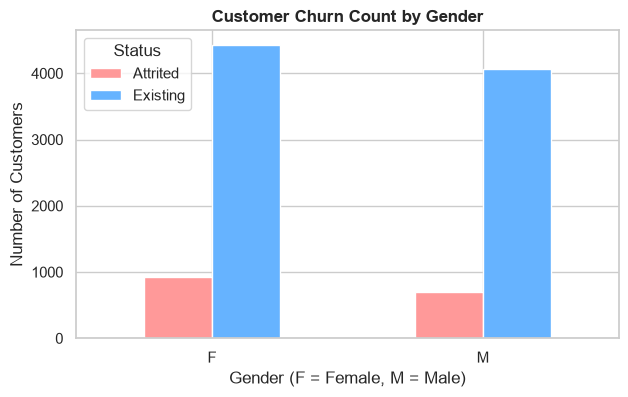

In [25]:
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Count churn by gender
gender_churn = df.groupby(['Gender', 'Attrition_Flag']).size().unstack()

# Plot simple side-by-side bar representation with custom gender markers
fig, ax = plt.subplots(figsize=(7, 4))
gender_churn.plot(kind='bar', stacked=False, color=['#ff9999', '#66b3ff'], ax=ax)

plt.title('Customer Churn Count by Gender', fontsize=12, fontweight='bold')
plt.xlabel('Gender (F = Female, M = Male)')
plt.ylabel('Number of Customers')
plt.legend(['Attrited', 'Existing'], title='Status')
plt.xticks(rotation=0)

plt.show()

### 2.3 Income Distribution Across Churn Status

_Comparing churn status across income categories to see whether income level relates to churn behaviour._

In [26]:
import plotly.express as px

# Calculate count of customers by Income Category and Attrition Status
income_df = df.groupby(['Income_Category', 'Attrition_Flag']).size().reset_index(name='Count')

# Plot interactive horizontal bar chart
fig = px.bar(
    income_df, 
    x='Count', 
    y='Income_Category', 
    color='Attrition_Flag',
    barmode='group',
    title='Customer Count by Income Category & Churn Status',
    labels={'Income_Category': 'Income Category', 'Count': 'Number of Customers', 'Attrition_Flag': 'Status'},
    color_discrete_sequence=['#ff9999', '#66b3ff']
)

fig.update_layout(height=450, width=750)
fig.show()

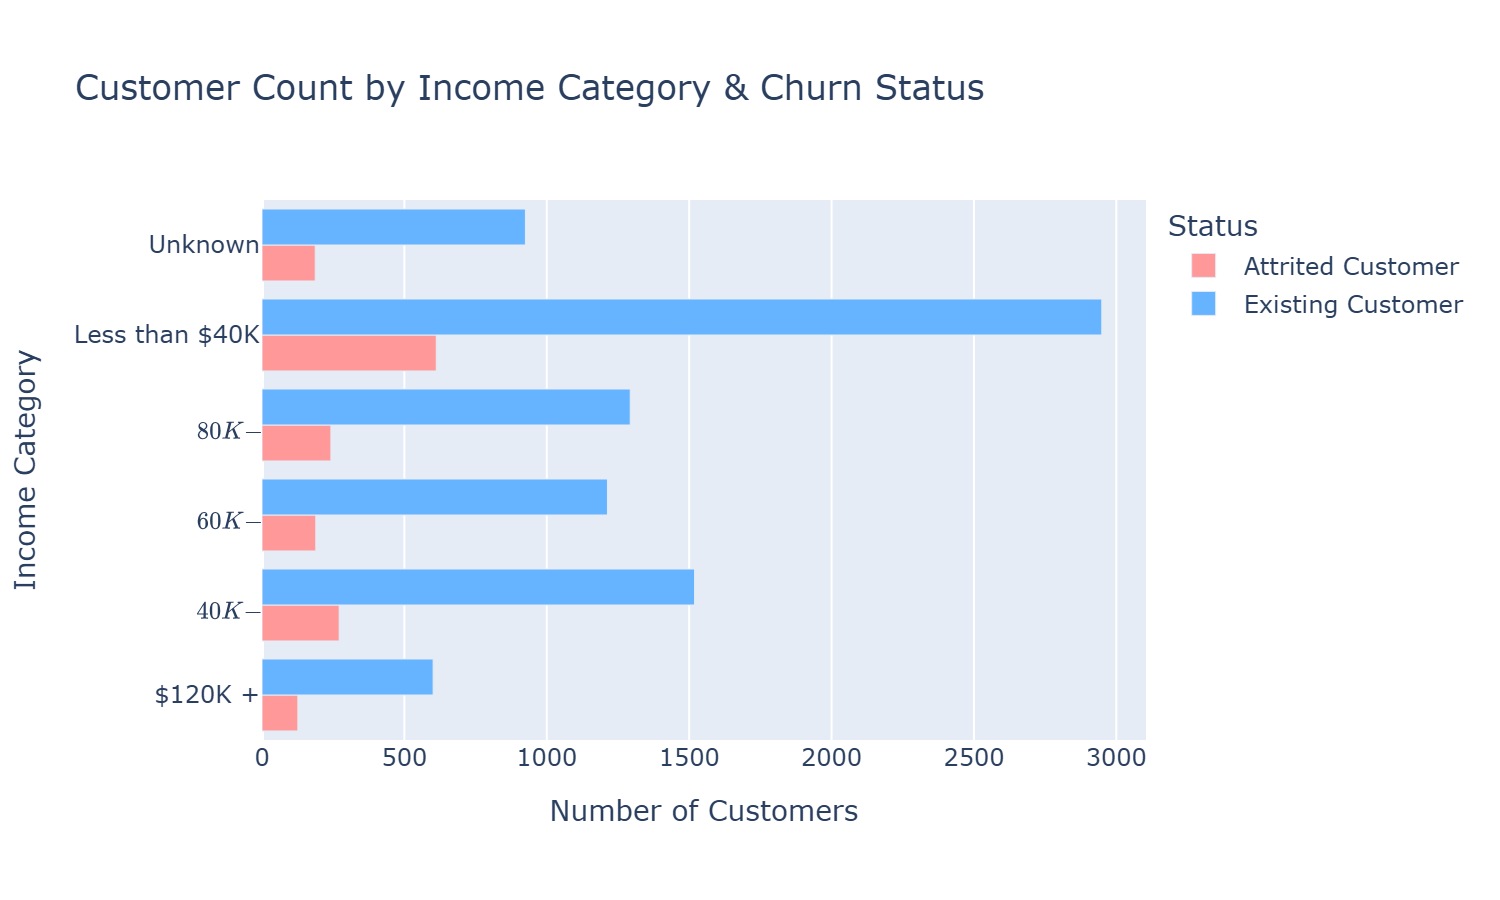

In [27]:
fig.write_image("../images/income_churn_plotly.png", scale=2) # save the plot as a static image with higher resolution

from IPython.display import Image
Image("../images/income_churn_plotly.png") #to display the saved image in the notebook as static image

In [28]:
income_churn = pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index') * 100 # calculate percentage of churn within each income category
income_churn 

Attrition_Flag,Attrited Customer,Existing Customer
Income_Category,,
$120K +,17.331499,82.668501
$40K - $60K,15.139665,84.860335
$60K - $80K,13.480742,86.519258
$80K - $120K,15.765472,84.234528
Less than $40K,17.186184,82.813816
Unknown,16.816547,83.183453


**Conclusion:** Raw counts point to "Less than $40K" as the biggest churn group, but churn *rate* tells a different story , $120K+ earners actually churn the most (17.3%), while mid-income brackets churn the least. Income shows a U-shaped, not linear, relationship with churn, so retention efforts shouldn't focus on low-income customers alone.

## 3.1 Correlation Analysis

_Calculating correlation between all numeric behavioural/financial features and churn status, to identify which factors are most worth investigating further. 
Attrition_Flag is temporarily converted to a 0/1 flag purely for this correlation calculation — this is not saved back into the main dataset or used for any modelling._

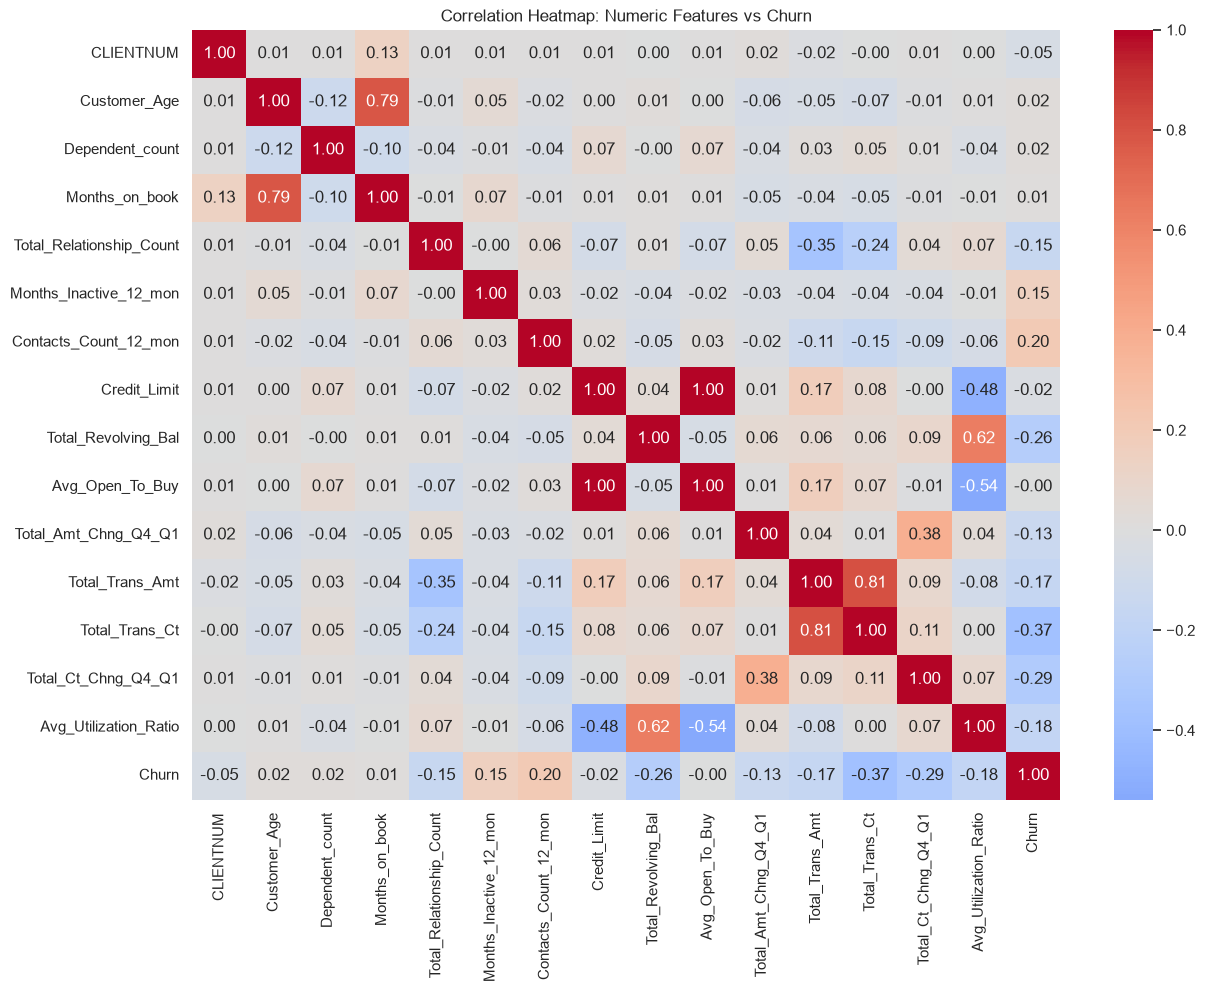

In [29]:
# Temporary numeric version of churn status, just for correlation — not saved to df
churn_numeric = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# Combine numeric columns with this temporary churn flag
corr_data = df.select_dtypes(include='number').copy() #take only numeric columns for correlation analysis
corr_data['Churn'] = churn_numeric # add the numeric churn flag

# Calculate correlation matrix
corr_matrix = corr_data.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0) # fmt='.2f' for two decimal places, center=0 to center the colormap at 0
plt.title('Correlation Heatmap: Numeric Features vs Churn')
plt.show()

### Key Churn Insights: Behavioral Triggers vs. Demographics

* **Behavior Over Demographics**: Operational customer activity (how they use the card) predicts churn far better than demographic factors like age or gender.
* **Primary Churn Triggers**:
  * **Declining Transaction Count ($r = -0.37$)**: Fewer yearly card swipes is the single strongest indicator of an at-risk customer.
  * **Quarter-over-Quarter Activity Drop ($r = -0.29$)**: A sudden slowdown in recent monthly usage signals imminent churn.
* **Secondary Financial Signals**: Low revolving balances and low card utilization rates consistently align with customer exit.
* **Customer Contact Warning Sign ($r = +0.20$)**: Higher customer service outreach correlates with *higher* churn, suggesting customers call to resolve issues right before cancelling.
* **Strategic Takeaway**: The bank must build an automated early-warning system around usage thresholds (e.g., transaction dips) rather than demographic profiling.

### 3.2 Top Churn-Correlated Factors

_Isolating and ranking all features by their correlation strength with churn, to clearly identify the top drivers worth investigating further._

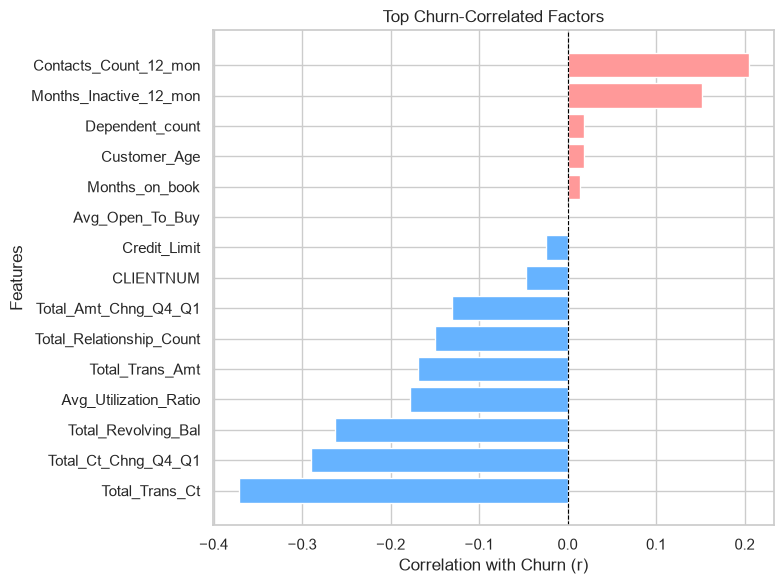

In [32]:
# Get correlation of all features with Churn, excluding Churn itself
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(8,6))
colors = ['#66b3ff' if val < 0 else '#ff9999' for val in churn_corr]
plt.barh(churn_corr.index, churn_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Correlation with Churn (r)')
plt.ylabel('Features')
plt.title('Top Churn-Correlated Factors')
plt.tight_layout()
plt.show()

### Key Observations: 

* **Primary Risk Drivers (Behavioral)**: 
  * **Declining Transaction Count ($r = -0.37$)**: The strongest single indicator; fewer annual swipes strongly aligns with churn.
  * **Quarter-over-Quarter Activity Drop ($r = -0.29$)**: A sudden drop in recent transaction velocity signals high risk.
* **Secondary Financial Signals**:
  * **Low Revolving Balance ($r = -0.26$)** & **Low Card Utilization ($r = -0.18$)**: Underutilized cards and low balances precede account closures.
* **Warning Flags (Positive Correlations)**:
  * **High Customer Contact ($r = +0.20$)**: More calls to customer service correlate with higher churn, suggesting unresolved issues before leaving.
  * **Inactivity ($r = +0.15$)**: More inactive months directly pushes risk upward.
* **Irrelevant Metrics**:
  * **Demographics & Identifiers**: Age ($r = 0.02$), Credit Limit ($r = -0.02$), and Client ID show virtually zero relationship with churn.

## 4. Predictive Analysis (Risk-Pattern Indicators)
### 4.1 Total Transaction Count: Churned vs Active

_Total_Trans_Ct showed the strongest correlation with churn (-0.37). Comparing the distribution directly between churned and active customers to see how large the gap actually is._

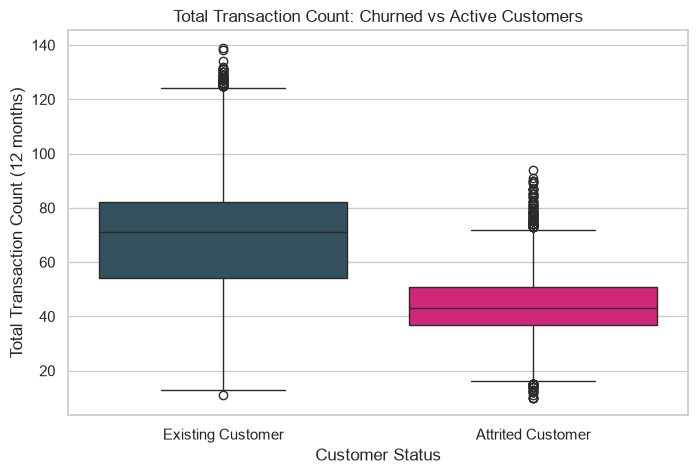

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct', hue='Attrition_Flag', 
            palette=['#2c5364', '#ee0979'], legend=False)
plt.title('Total Transaction Count: Churned vs Active Customers')
plt.xlabel('Customer Status')
plt.ylabel('Total Transaction Count (12 months)')
plt.show()

### Key Churn Insight: Transaction Count Threshold

* **Significant Activity Gap**: Active customers complete a median of **~70 transactions** per year, whereas churned customers drop to a median of **~43 transactions**.
* **Minimal Group Overlap**: The separation between active and churned distribution peaks makes transaction frequency one of the strongest individual risk signals.
* **Operational Risk Trigger**: Customers whose annual activity falls below **50–55 transactions** enter a high-risk zone for account closure.
* **Proactive Strategy**: The bank should establish an automated early-warning system that flags accounts dropping below this 50-transaction threshold for targeted retention campaigns.

### 4.2 Transaction Count vs Transaction Amount (Customer Segmentation)

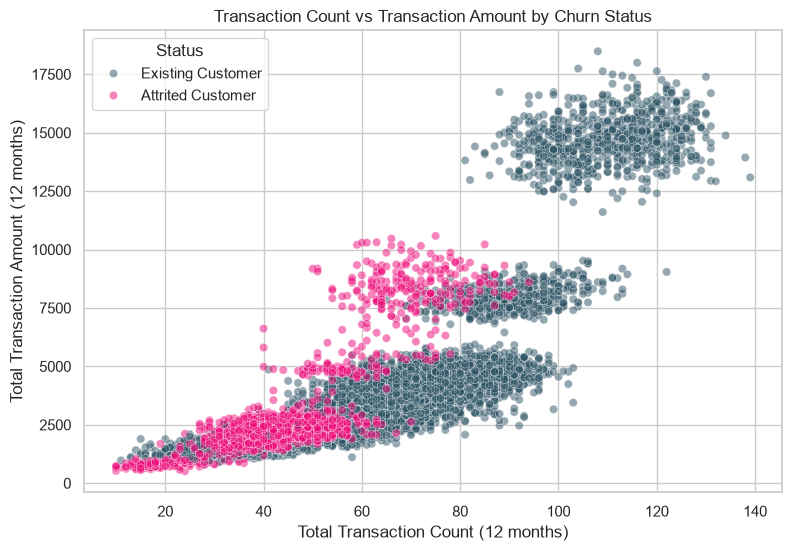

In [ ]:
#Plotting transaction count against transaction amount, coloured by churn status, to see whether churned customers cluster into a distinct, identifiable segment.
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Total_Trans_Ct', y='Total_Trans_Amt', 
                 hue='Attrition_Flag', palette=['#2c5364', '#ee0979'], alpha=0.5)
plt.title('Transaction Count vs Transaction Amount by Churn Status')
plt.xlabel('Total Transaction Count (12 months)')
plt.ylabel('Total Transaction Amount (12 months)')
plt.legend(title='Status')
plt.show()

### Key Churn Insight: Mid-Tier Activity Risk Cluster

* **Risk Concentration**: Churned customers form a distinct cluster in the mid-activity range (**30–90 transactions**, **£1,000–£10,000 spend**), rather than just at the lowest end.
* **High-Value Loyalty**: High-activity customers (**100+ transactions**) are almost exclusively active, showing virtually zero churn risk.
* **Targeted Retention Strategy**: Retention campaigns should focus specifically on low-mid tier accounts showing signs of plateauing, rather than treating "low activity" as a single uniform risk group.

### 4.3 Revolving Balance & Utilization Ratio: Churned vs Active

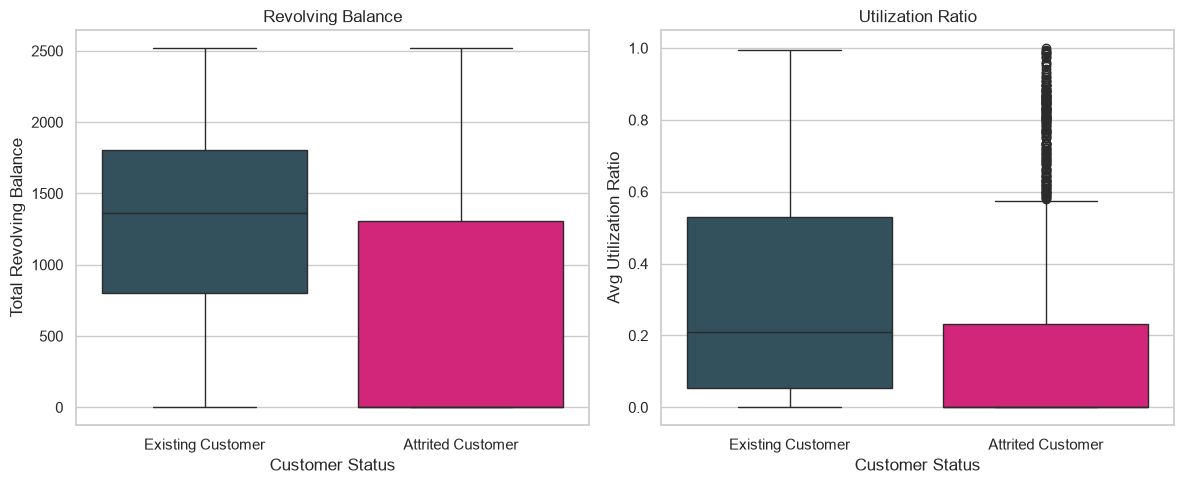

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', hue='Attrition_Flag',
            palette=['#2c5364', '#ee0979'], legend=False, ax=axes[0]) #to create a boxplot for Total Revolving Balance by Attrition Flag    
axes[0].set_title('Revolving Balance')
axes[0].set_xlabel('Customer Status')
axes[0].set_ylabel('Total Revolving Balance')

sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Utilization_Ratio', hue='Attrition_Flag',
            palette=['#2c5364', '#ee0979'], legend=False, ax=axes[1]) #to create a boxplot for Average Utilization Ratio by Attrition Flag
axes[1].set_title('Utilization Ratio')
axes[1].set_xlabel('Customer Status')
axes[1].set_ylabel('Avg Utilization Ratio')

plt.tight_layout()
plt.show()

### Key Observations: Revolving Balance & Card Utilization

* **Lower Revolving Balances**: Attrited customers maintain a lower revolving balance (median ~1,300, mostly below 1,400) compared to active customers (median ~1,360, extending up to 1,800).
* **Underutilized Credit Lines**: Attrited customers predominantly sit at utilization ratios below 0.3, whereas active customers show broader engagement up to ~0.5.
* **Unified Risk Profile**: Low revolving balance, low utilization, and low transaction count together form a clear 3-part behavioral warning profile for proactive monitoring.

### 4.4 Months Inactive & Contacts Count: Churned vs Active

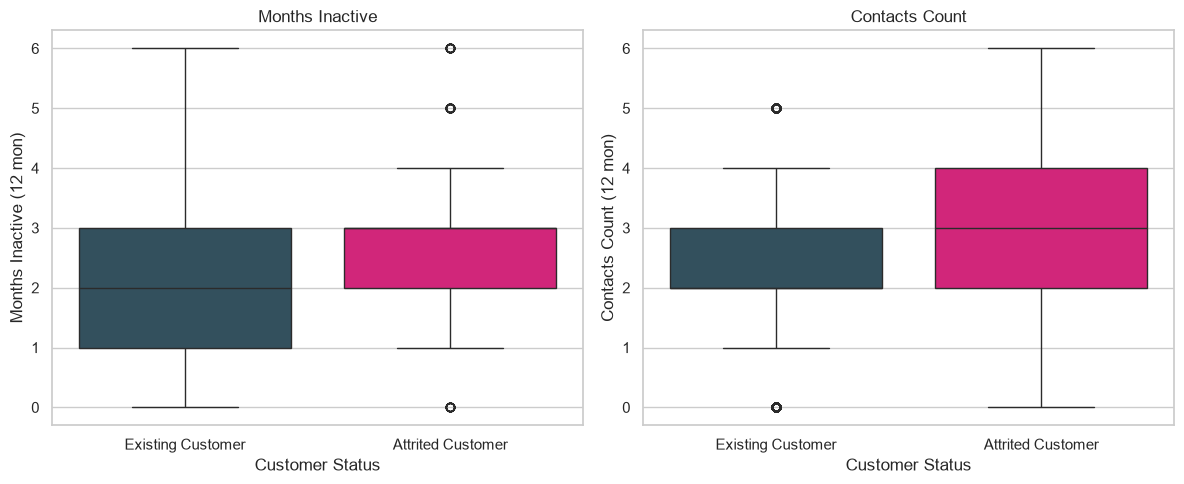

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='Attrition_Flag', y='Months_Inactive_12_mon', hue='Attrition_Flag',
            palette=['#2c5364', '#ee0979'], legend=False, ax=axes[0]) #to create a boxplot for Months Inactive by Attrition Flag
axes[0].set_title('Months Inactive')
axes[0].set_xlabel('Customer Status')
axes[0].set_ylabel('Months Inactive (12 mon)')

sns.boxplot(data=df, x='Attrition_Flag', y='Contacts_Count_12_mon', hue='Attrition_Flag',
            palette=['#2c5364', '#ee0979'], legend=False, ax=axes[1]) #to create a boxplot for Contacts Count by Attrition Flag
axes[1].set_title('Contacts Count')
axes[1].set_xlabel('Customer Status')
axes[1].set_ylabel('Contacts Count (12 mon)')

plt.tight_layout()
plt.show()

### Key Observations: Inactivity vs. Customer Contact Count

* **Inactivity is Non-Predictive**: Inactive months alone show virtually no difference between churned and active customers (both medians sit at 2–3 months), making it an unreliable standalone signal.
* **Support Contact is a Clear Early Warning**: Attrited customers average a higher contact frequency (median 3 contacts vs. 2 for active), with churned accounts skewing noticeably higher overall.
* **Key Takeaway**: Rising customer contact count is a far more actionable warning sign than inactivity—customers reaching out more frequently are likely signaling frustration before leaving.

Click here for [Conclusion](Conclusion.ipynb) of this project, without using ML & FE.